# P(2) F1′=3/2 F′=1 — mF′-resolved scan vs electric field and X/Z polarization

Simulations to match CeNTREX **P(2) F1′=3/2 F′=1** data taken after rotational cooling, state
preparation A and the electrostatic lens, at a DC field somewhere in **150–250 V/cm**.

Three quantities are not known well enough to fix a priori and are scanned here:

1. **The DC electric field**, 150–250 V/cm. It Stark-splits the excited mF′ sublevels and pulls
   in the nearby **opposite-parity** (Λ-doublet) partner of B J′=1.
2. **The laser polarization** — mostly X̂ (⊥ **E**) with an unknown Ẑ (∥ **E**) admixture, up to
   30% in intensity. Parameterized by the Z intensity fraction

   ```text
   f_Z = |E_Z|^2 / (|E_X|^2 + |E_Z|^2),   ε = sqrt(1 - f_Z) X̂ + sqrt(f_Z) Ẑ
   ```

   so total optical power is held fixed as the polarization rotates.
3. **The optical power**, which controlled the peak ratios strongly in the earlier R(2) work.

The initial population is the lens-focused **mJ=0** manifold of X J=2, split by rotational
cooling into **2/3 nuclear-spin singlet** (F1=5/2, F=2, mF=0) and **1/3 triplet** (F1=5/2, F=3,
mF=0,±1). Only mJ=0 is modelled.

## Excited-state structure

B J′=1, F1′=3/2, F′=1 splits into four resolvable lines. Offsets in MHz relative to the
driven-parity |mF′|=1 pair (computed below, reproduced here as a reference):

**0 MHz is the middle of the three visible peaks**, the driven mF′=0 line. (The solver's own
`δ = 0` sits on the driven |mF′|=1 line, since `excited_main` is an mF′=1 level; everything
reported here is shifted into the middle-peak frame.)

| line | 150 V/cm | 200 V/cm | 250 V/cm |
|---|---|---|---|
| P′=−1 (driven), \|mF′\|=1 | −35.7 | −50.0 | −64.4 |
| **P′=−1 (driven), mF′=0** | **0** | **0** | **0** |
| P′=+1 (opposite), mF′=0 | 17.6 | 17.6 | 17.5 |
| P′=+1 (opposite), \|mF′\|=1 | 53.3 | 67.5 | 81.8 |

±mF′ stay degenerate because **E** ∥ ẑ. In this frame the opposite mF′=0 line barely moves with
field — it sits at the 17.7 MHz Λ-doublet splitting, which is what the whole pattern collapses to
at zero field. The F′=2 manifold sits at ~310–390 MHz and is deliberately outside the scan
window — F′ is also a poor label there at these fields.

The **mF′=0 lines are the polarization-sensitive ones**: they are driven by the Ẑ component, so
their height relative to the |mF′|=1 lines measures f_Z.

## Notes

- Results are cached to `_cache/*.npz`. Re-running the notebook reloads them instead of
  re-solving; delete the files or bump `CACHE_VERSION` to force a recompute.
- Two traps specific to this system, both handled below: excited levels must be read from the
  `H_symbolic` diagonal (not `H_int`), and the four initial levels must be selected by quantum-number
  label rather than energy ordering, because their ordering flips between 200 and 250 V/cm.

In [1]:
from __future__ import annotations

import inspect
import json
import time
import warnings
from dataclasses import dataclass
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.constants as cst
import sympy as smp
from matplotlib.colors import LogNorm

from centrex_tlf import couplings, hamiltonian, lindblad, states, transitions
from centrex_tlf.couplings.polarization import Polarization
from centrex_tlf.utils import population
from centrex_tlf.utils.rabi import (
    power_to_intensity_rectangular_beam,
    power_to_rabi_rectangular_beam,
)

plt.rcParams.update({"font.size": 12, "figure.dpi": 110})

GAMMA = getattr(hamiltonian, "Γ")
print(f"Γ = {GAMMA:.4e} rad/s = 2π × {GAMMA / (2 * np.pi * 1e6):.3f} MHz")

Γ = 9.8018e+06 rad/s = 2π × 1.560 MHz


## Configuration

In [2]:
transition = transitions.P2_F1_3o2_F1

# --- scanned axes -------------------------------------------------------------------
# Coarse coverage of the 150-250 V/cm range, refined around 168 V/cm where the
# measured line positions place the field (see the comparison section).
E_FIELDS = np.array([150.0, 160.0, 164.0, 168.0, 172.0, 176.0, 180.0,
                     200.0, 225.0, 250.0])                     # V/cm, along z
Z_FRACTIONS = np.array([0.0, 0.01, 0.03, 0.05, 0.10, 0.20, 0.30])   # f_Z, intensity fraction

# --- fixed fields and beam ----------------------------------------------------------
B_FIELD = np.array([0.0, 0.0, 1e-5])            # G; not exactly 0, X states go degenerate
POWER_MW = 40.0
POWER_W = POWER_MW * 1e-3
# Flat-top rectangle, 2 cm × 1.5 cm. x is along the molecular beam, y is vertical,
# so BEAM_WX is also the interaction length; only the product enters the intensity.
BEAM_WX = 0.02                                  # m, along the molecular beam
BEAM_WY = 0.015                                 # m, vertical
VELOCITY = 184.0                                # m/s
INTERACTION_LENGTH = BEAM_WX                    # m, along-beam beam width
T_END = INTERACTION_LENGTH / VELOCITY

# --- Hamiltonian truncation ---------------------------------------------------------
# Defaults (X 0…J'+2, B 1…J'+2) are already converged here: raising Jmax_X to 7 shifts
# X J=2 energies by 0.03 kHz and leaves main_coupling identical to 6 digits. Set
# explicitly so the choice is recorded in the cache.
JMAX_X, JMAX_B = 4, 4

# --- detuning grid ------------------------------------------------------------------
DETUNING_STEP_MHZ = 0.5                 # << natural linewidth 1.56 MHz
DETUNING_PAD_SIGMA = 8.0                # window padding, in Doppler sigmas

# --- transverse Doppler -------------------------------------------------------------
TRANSVERSE_VELOCITY_SIGMA = 1.4         # m/s
OPTICAL_FREQUENCY_HZ = 1.1e15
DOPPLER_SIGMA_MHZ = OPTICAL_FREQUENCY_HZ * TRANSVERSE_VELOCITY_SIGMA / cst.c / 1e6

# --- power axis (run on a subset of the grid) ---------------------------------------
POWER_SCAN_MW = np.array([5.0, 15.0, 40.0, 60.0, 100.0])
POWER_SCAN_E_FIELDS = np.array([150.0, 200.0, 250.0])
POWER_SCAN_Z_FRACTIONS = np.array([0.0, 0.05, 0.30])
POWER_SCAN_DETUNING_STEP_MHZ = 1.0      # peaks are read off Doppler-broadened spectra

# --- initial population: lens-focused mJ=0 manifold ---------------------------------
# Rotational cooling puts 2/3 into the nuclear-spin singlet and 1/3 into the triplet.
INITIAL_SELECTORS = [
    states.QuantumSelector(electronic=states.ElectronicState.X, J=2, F1=5 / 2, F=2, mF=0),
    states.QuantumSelector(electronic=states.ElectronicState.X, J=2, F1=5 / 2, F=3, mF=-1),
    states.QuantumSelector(electronic=states.ElectronicState.X, J=2, F1=5 / 2, F=3, mF=0),
    states.QuantumSelector(electronic=states.ElectronicState.X, J=2, F1=5 / 2, F=3, mF=+1),
]
INITIAL_WEIGHTS = np.array([2 / 3, 1 / 9, 1 / 9, 1 / 9])

# --- solver -------------------------------------------------------------------------
SOLVER = "dopri5"
EXECUTION_MODE = "expanded_sparse"
SOLVER_DT = 2e-9
SOLVER_RELTOL = 1e-7
SOLVER_ABSTOL = 1e-9
SCAN_THREADS = None                     # None -> let Rust choose

# --- caching ------------------------------------------------------------------------
CACHE_VERSION = 3          # 40 mW in a 2 cm × 1.5 cm beam
POWER_CACHE_VERSION = 2    # power axis rebuilt for the new beam area
# Anchor the cache next to this notebook, so it does not depend on the working
# directory the kernel happens to start in.
_NB_DIR = Path.cwd()
if _NB_DIR.name != "lindblad" and (_NB_DIR / "examples" / "lindblad").is_dir():
    _NB_DIR = _NB_DIR / "examples" / "lindblad"
CACHE_DIR = _NB_DIR / "_cache"
CACHE_DIR.mkdir(exist_ok=True)
FIGURE_DIR = _NB_DIR / "p2_f1_3o2_f1_images"
FIGURE_DIR.mkdir(exist_ok=True)
BEAM_TAG = f"{BEAM_WX * 100:g}x{BEAM_WY * 100:g}cm"
MAIN_CACHE = CACHE_DIR / (
    f"p2_f1_3o2_f1_mf_scan_E{E_FIELDS.min():.0f}-{E_FIELDS.max():.0f}"
    f"_fz0-{Z_FRACTIONS.max():g}_{POWER_MW:.0f}mW_{BEAM_TAG}_v{CACHE_VERSION}.npz"
)
POWER_CACHE = CACHE_DIR / f"p2_f1_3o2_f1_power_scan_{BEAM_TAG}_v{POWER_CACHE_VERSION}.npz"

config = {
    "transition": transition.name,
    "J_ground": transition.J_ground,
    "J_excited": transition.J_excited,
    "P_excited": transition.P_excited,
    "E_fields_V_per_cm": E_FIELDS.tolist(),
    "z_intensity_fractions": Z_FRACTIONS.tolist(),
    "power_mW": POWER_MW,
    "beam_cm": [BEAM_WX * 100, BEAM_WY * 100],
    "intensity_mW_per_cm2": power_to_intensity_rectangular_beam(POWER_W, BEAM_WX, BEAM_WY) * 0.1,
    "velocity_m_per_s": VELOCITY,
    "interaction_time_us": T_END * 1e6,
    "doppler_sigma_MHz": DOPPLER_SIGMA_MHZ,
    "Jmax_X": JMAX_X,
    "Jmax_B": JMAX_B,
    "main_cache": str(MAIN_CACHE),
}
config

{'transition': "P(2) F1'=3/2 F'=1",
 'J_ground': 2,
 'J_excited': 1,
 'P_excited': -1,
 'E_fields_V_per_cm': [150.0,
  160.0,
  164.0,
  168.0,
  172.0,
  176.0,
  180.0,
  200.0,
  225.0,
  250.0],
 'z_intensity_fractions': [0.0, 0.01, 0.03, 0.05, 0.1, 0.2, 0.3],
 'power_mW': 40.0,
 'beam_cm': [2.0, 1.5],
 'intensity_mW_per_cm2': 13.333333333333336,
 'velocity_m_per_s': 184.0,
 'interaction_time_us': 108.69565217391305,
 'doppler_sigma_MHz': 5.136887066051542,
 'Jmax_X': 4,
 'Jmax_B': 4,
 'main_cache': 'C:\\Users\\ogras\\Documents\\GitHub\\CeNTREX-TlF\\examples\\lindblad\\_cache\\p2_f1_3o2_f1_mf_scan_E150-250_fz0-0.3_40mW_2x1.5cm_v3.npz'}

## Polarization

`ε = sqrt(1 - f_Z) X̂ + sqrt(f_Z) Ẑ`, normalized, so the total optical power is independent of
`f_Z`. Note that a small intensity fraction is a much larger *field-amplitude* admixture:
`f_Z = 0.01` is only 1% of the power but `E_Z/E_X ≈ 0.1`.

In [3]:
def xz_polarization(z_intensity_fraction: float) -> Polarization:
    """Normalized ε = sqrt(1-f_Z) X̂ + sqrt(f_Z) Ẑ."""
    fz = float(z_intensity_fraction)
    if not 0.0 <= fz <= 1.0:
        raise ValueError(f"z_intensity_fraction must be in [0, 1], got {fz}")
    vector = np.array([np.sqrt(1.0 - fz), 0.0, np.sqrt(fz)], dtype=np.complex128)
    # Keep the name short; the actual vector lives in the TransitionSelector.
    return Polarization(vector=vector, name=f"XZ{fz:.6g}")


pd.DataFrame(
    [
        {
            "f_Z": float(fz),
            "f_X": float(1 - fz),
            "E_z/E_x": float(np.sqrt(fz / (1 - fz))) if fz < 1 else np.inf,
            "tilt angle (deg)": float(np.degrees(np.arcsin(np.sqrt(fz)))),
            "norm": xz_polarization(float(fz)).norm,
        }
        for fz in Z_FRACTIONS
    ]
)

,f_Z,f_X,E_z/E_x,tilt angle (deg),norm
0,0.00,1.00,0.000000,0.000000,1.0
1,0.01,0.99,0.100504,5.739170,1.0
2,0.03,0.97,0.175863,9.974222,1.0
3,0.05,0.95,0.229416,12.920966,1.0
4,0.10,0.90,0.333333,18.434949,1.0
5,0.20,0.80,0.500000,26.565051,1.0
6,0.30,0.70,0.654654,33.210911,1.0


## Model construction

One OBE system per `(E, f_Z)` pair — the polarization vector enters the coupling matrix, so a new
`f_Z` needs a rebuild. Builds are `lru_cache`d on **integer grid indices** so repeated access is
free and floating-point keys never mismatch.

`excited_main` is deliberately an **mF′=±1** level: it is X̂-driven, so `main_coupling` stays
finite as `f_Z → 0`. An mF′=0 choice would make the power→Rabi conversion divide by zero at pure X
polarization.

In [4]:
ground_main = 1 * next(
    iter(
        states.generate_coupled_states_X(
            states.QuantumSelector(
                electronic=states.ElectronicState.X,
                J=transition.J_ground,
                F1=5 / 2,
                F=2,
                mF=0,
                P=transition.P_ground,
            )
        )
    )
)

excited_main = 1 * next(
    iter(
        states.generate_coupled_states_B(
            states.QuantumSelector(
                electronic=states.ElectronicState.B,
                J=transition.J_excited,
                F1=transition.F1_excited,
                F=transition.F_excited,
                mF=1,
                P=transition.P_excited,
            )
        )
    )
)

print("ground_main :", ground_main.largest.state_string_custom(["J", "F1", "F", "mF"]))
print("excited_main:", excited_main.largest.state_string_custom(["J", "F1", "F", "mF", "P"]))


def build_parameters(
    system: lindblad.OBESystem, selector: couplings.TransitionSelector
) -> lindblad.LindbladParameters:
    """Bind every free symbol of H_symbolic; unbound symbols make preparation fail."""
    params = lindblad.LindbladParameters()
    rabi = params.real("rabi", 0.0)
    detuning = params.real("detuning", 0.0)

    for symbol in system.H_symbolic.free_symbols:
        if symbol in system.coupling_symbols:
            params.bind(symbol, rabi, finalize=False)
        elif str(symbol) == str(getattr(selector, "δ")):
            params.bind(symbol, detuning, finalize=False)
        else:
            params.real(str(symbol), 0.0)

    # The polarization vector is already inside the coupling matrix; these symbols are the
    # amplitudes of each field component.
    for group in system.polarization_symbols:
        for symbol in group if isinstance(group, (list, tuple)) else [group]:
            params.bind(symbol, 1.0, finalize=False)

    params._finalize()
    return params


def initial_density_matrix(system: lindblad.OBESystem) -> np.ndarray:
    """2/3 singlet + 1/3 triplet over the lens-focused mJ=0 levels, selected by label.

    Selection is by quantum number, never by energy: the F=3 mF=±1 pair drops below the
    F=2 mF=0 level between 200 and 250 V/cm.
    """
    groups = []
    for selector in INITIAL_SELECTORS:
        idx = np.asarray(selector.get_indices(system.QN), dtype=int).ravel()
        if idx.size != 1:
            raise ValueError(f"selector matched {idx.size} states, expected exactly 1: {selector}")
        groups.append(idx)

    indices = np.concatenate(groups)
    weights = np.concatenate(
        [np.full(g.size, w / g.size, dtype=float) for g, w in zip(groups, INITIAL_WEIGHTS)]
    )

    # generate_uniform_population_state_indices is defined twice in utils/population.py;
    # only the shadowing definition takes `weights`.
    if "weights" in inspect.signature(population.generate_uniform_population_state_indices).parameters:
        return population.generate_uniform_population_state_indices(
            indices, len(system.QN), weights=weights
        )
    rho0 = np.zeros((len(system.QN),) * 2, dtype=np.complex128)
    np.add.at(rho0, (indices, indices), weights)
    return rho0 / np.trace(rho0)


@dataclass(frozen=True)
class PreparedModel:
    e_index: int
    z_index: int
    E_field: float
    z_fraction: float
    selector: couplings.TransitionSelector
    system: lindblad.OBESystem
    params: lindblad.LindbladParameters
    prepared: object
    rho0: np.ndarray
    photon_weights: list[tuple[int, float]]
    main_coupling: float
    build_seconds: float

    def rabi_for_power(self, power_w: float) -> float:
        return power_to_rabi_rectangular_beam(power_w, self.main_coupling, BEAM_WX, BEAM_WY)


BUILD_LOG: list[dict] = []


@lru_cache(maxsize=None)
def build_model(e_index: int, z_index: int) -> PreparedModel:
    E_field = float(E_FIELDS[e_index])
    fz = float(Z_FRACTIONS[z_index])

    start = time.perf_counter()
    selectors = couplings.generate_transition_selectors(
        transitions=[transition],
        polarizations=[[xz_polarization(fz)]],
        ground_mains=[ground_main],
        excited_mains=[excited_main],
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        system = lindblad.generate_OBE_system_transitions(
            [transition],
            selectors,
            qn_compact=True,
            E=np.array([0.0, 0.0, E_field]),
            B=B_FIELD,
            retain_opposite_parity_levels=True,
            normalize_pol=True,
            Jmax_X=JMAX_X,
            Jmax_B=JMAX_B,
        )
    params = build_parameters(system, selectors[0])
    prepared = lindblad.prepare_lindblad_problem(
        system, params, backend="rust", hamiltonian_representation="decomposed"
    )
    weights = [
        (i, float(GAMMA))
        for i, s in enumerate(system.QN)
        if s.largest.electronic_state == states.ElectronicState.B
    ]
    rho0 = initial_density_matrix(system)
    elapsed = time.perf_counter() - start

    BUILD_LOG.append(
        {
            "e_index": e_index,
            "z_index": z_index,
            "E_field": E_field,
            "f_Z": fz,
            "levels": len(system.QN),
            "excited_levels": len(weights),
            "build_seconds": elapsed,
        }
    )

    return PreparedModel(
        e_index=e_index,
        z_index=z_index,
        E_field=E_field,
        z_fraction=fz,
        selector=selectors[0],
        system=system,
        params=params,
        prepared=prepared,
        rho0=rho0,
        photon_weights=weights,
        main_coupling=abs(system.couplings[0].main_coupling),
        build_seconds=elapsed,
    )

ground_main : |J = 2, F1 = 5/2, F = 2, mF = 0>
excited_main: |J = 1, F1 = 3/2, F = 1, mF = 1, P = ->


### Verification of the built model

In [5]:
_m = build_model(0, 0)
_qn = _m.system.QN
_n_x = sum(1 for s in _qn if s.largest.electronic_state == states.ElectronicState.X)
_n_b = len(_qn) - _n_x

assert len(_qn) == 29, f"expected 29 levels, got {len(_qn)}"
assert (_n_x, _n_b) == (23, 6), f"expected 23 X / 6 B levels, got {_n_x} / {_n_b}"
assert _m.main_coupling > 0, "main_coupling must be non-zero"

_diag = np.real(np.diag(_m.rho0))
assert np.count_nonzero(_diag) == 4, f"expected 4 populated levels, got {np.count_nonzero(_diag)}"
assert np.isclose(_diag.sum(), 1.0), f"rho0 trace = {_diag.sum()}"
assert np.isclose(_diag.max(), 2 / 3), "singlet level should carry 2/3 of the population"

print(f"levels: {len(_qn)}  (X: {_n_x}, B: {_n_b})")
print(f"main_coupling: {_m.main_coupling:.6f}")
print(f"Rabi at {POWER_MW:g} mW: {_m.rabi_for_power(POWER_W) / (2 * np.pi * 1e6):.4f} MHz"
      f"  ({_m.rabi_for_power(POWER_W) / GAMMA:.3f} Γ)")
print(f"build time: {_m.build_seconds:.2f} s")
print("\ninitial population:")
for i in np.flatnonzero(_diag):
    q = _qn[i].largest
    print(f"  idx {i:3d}  w={_diag[i]:.4f}  "
          f"J={q.J} F1={float(q.F1):.1f} F={q.F} mF={q.mF:+d}")

levels: 29  (X: 23, B: 6)
main_coupling: 0.094144
Rabi at 40 mW: 0.1201 MHz  (0.077 Γ)
build time: 1.29 s

initial population:
  idx  12  w=0.6667  J=2 F1=2.5 F=2 mF=+0
  idx  17  w=0.1111  J=2 F1=2.5 F=3 mF=-1
  idx  18  w=0.1111  J=2 F1=2.5 F=3 mF=+0
  idx  19  w=0.1111  J=2 F1=2.5 F=3 mF=+1


## Excited-level structure

Line positions come from the **`H_symbolic` diagonal at δ=0**, which is the rotating-frame offset
actually used by the solver. (`H_int` carries a different energy origin for the B block and gives
numbers that are wrong by orders of magnitude.)

In [6]:
LINE_ORDER = [("driven", 1), ("driven", 0), ("opposite", 0), ("opposite", 1)]
LINE_LABELS = {
    ("driven", 1): "driven |mF'|=1",
    ("driven", 0): "driven mF'=0",
    ("opposite", 0): "opposite mF'=0",
    ("opposite", 1): "opposite |mF'|=1",
}
LINE_COLORS = {
    ("driven", 1): "tab:blue",
    ("driven", 0): "tab:orange",
    ("opposite", 0): "tab:red",
    ("opposite", 1): "tab:green",
}

# Two frames are in play, and keeping them apart matters.
#
#   delta frame  - the solver's own. delta = 0 is resonance with ground_main -> excited_main,
#                  and excited_main is an mF'=1 level, so delta = 0 sits on the driven |mF'|=1
#                  line. DETUNING_MHZ, every grid_scan call and every cached spectrum use this.
#   report frame - what is plotted and quoted: 0 MHz on the middle of the three visible peaks,
#                  the driven mF'=0 line.
#
# The two differ by a rigid per-field shift, so the frame is purely a relabelling: it cannot
# change a spectrum, and the data fit absorbs it exactly into the profiled frequency origin.
REFERENCE_LINE = ("driven", 0)


def to_reference_frame(centers: dict[tuple[str, int], float]) -> dict[tuple[str, int], float]:
    """Shift delta-frame line centres so REFERENCE_LINE sits at 0."""
    shift = centers[REFERENCE_LINE]
    return {key: value - shift for key, value in centers.items()}


def excited_level_table(model: PreparedModel) -> pd.DataFrame:
    """Excited-level offsets (MHz) in the delta frame, i.e. zeroed on driven |mF'|=1."""
    subs = {getattr(model.selector, "δ"): 0}
    rows = []
    for i, state in enumerate(model.system.QN):
        q = state.largest
        if q.electronic_state != states.ElectronicState.B:
            continue
        value = complex(smp.N(model.system.H_symbolic[i, i].subs(subs))).real
        rows.append(
            {
                "index": i,
                "offset_MHz": value / (2 * np.pi * 1e6),
                "F1": float(q.F1),
                "F": q.F,
                "mF": q.mF,
                "P": q.P,
                "parity": "driven" if q.P == transition.P_excited else "opposite",
                "abs_mF": abs(q.mF),
            }
        )
    df = pd.DataFrame(rows)
    zero = df.loc[(df["parity"] == "driven") & (df["abs_mF"] == 1), "offset_MHz"].mean()
    df["offset_MHz"] -= zero
    return df.sort_values("offset_MHz").reset_index(drop=True)


def line_centers(model: PreparedModel) -> dict[tuple[str, int], float]:
    df = excited_level_table(model)
    grouped = df.groupby(["parity", "abs_mF"])["offset_MHz"].mean()
    return {key: float(grouped.loc[key]) for key in LINE_ORDER}


_table = excited_level_table(build_model(2, 0))    # 200 V/cm
display(_table[["offset_MHz", "F1", "F", "mF", "P", "parity"]])

# _centers stays in the delta frame: common_detuning_grid builds the solver grid from it, and
# that grid must not move. _centers_ref is the reported version.
_centers = {E: line_centers(build_model(i, 0)) for i, E in enumerate(E_FIELDS)}
_centers_ref = {E: to_reference_frame(c) for E, c in _centers.items()}
centers_df = pd.DataFrame(
    {LINE_LABELS[k]: [_centers_ref[E][k] for E in E_FIELDS] for k in LINE_ORDER},
    index=pd.Index(E_FIELDS, name="E (V/cm)"),
)
display(centers_df.round(2))

# Cross-check against the values quoted in the header, in the reported frame.
for E, expected in [(150.0, [-35.7, 0.0, 17.6, 53.3]),
                    (200.0, [-50.0, 0.0, 17.6, 67.5]),
                    (250.0, [-64.4, 0.0, 17.5, 81.8])]:
    got = [_centers_ref[E][k] for k in LINE_ORDER]
    assert np.allclose(got, expected, atol=0.1), f"{E} V/cm: expected {expected}, got {got}"
    assert abs(_centers_ref[E][REFERENCE_LINE]) < 1e-9, "reference line must sit at exactly 0"
print("line positions match the reference table")

,offset_MHz,F1,F,mF,P,parity
0,-0.000004,1.5,1,1,-1,driven
1,0.000004,1.5,1,-1,-1,driven
2,39.678302,1.5,1,0,-1,driven
3,57.275261,1.5,1,0,1,opposite
4,96.928551,1.5,1,1,1,opposite
5,96.928558,1.5,1,-1,1,opposite


,driven |mF'|=1,driven mF'=0,opposite mF'=0,opposite |mF'|=1
E (V/cm),,,,
150.0,-35.68,0.0,17.61,53.27
160.0,-38.53,0.0,17.60,56.11
164.0,-39.68,0.0,17.60,57.25
168.0,-40.82,0.0,17.59,58.39
172.0,-41.97,0.0,17.59,59.53
176.0,-43.12,0.0,17.58,60.67
180.0,-44.26,0.0,17.58,61.81
200.0,-50.01,0.0,17.55,67.51
225.0,-57.21,0.0,17.50,74.65


line positions match the reference table


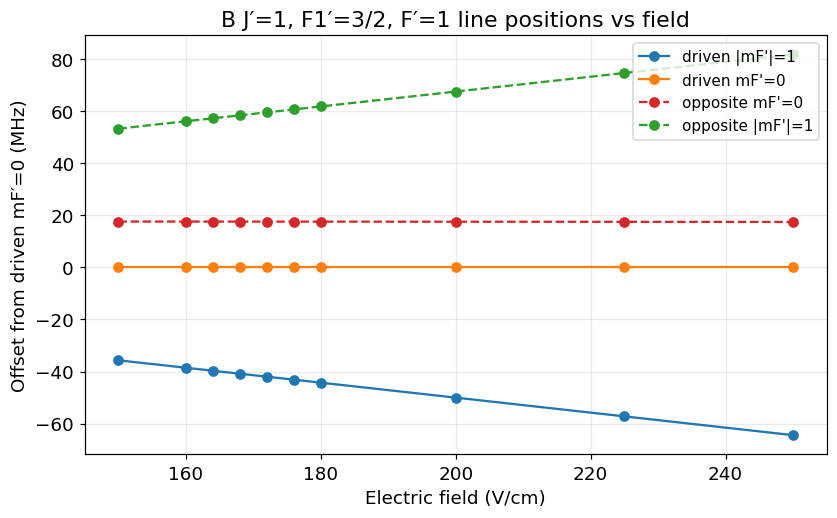

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.6), constrained_layout=True)
for key in LINE_ORDER:
    ax.plot(
        E_FIELDS,
        [_centers_ref[E][key] for E in E_FIELDS],
        marker="o",
        color=LINE_COLORS[key],
        ls="--" if key[0] == "opposite" else "-",
        label=LINE_LABELS[key],
    )
ax.set_xlabel("Electric field (V/cm)")
ax.set_ylabel("Offset from driven mF′=0 (MHz)")
ax.set_title("B J′=1, F1′=3/2, F′=1 line positions vs field")
ax.grid(alpha=0.25)
ax.legend(fontsize=10)
plt.show()

## Detuning grid, scan helper and Doppler convolution

A single detuning grid is shared by every `(E, f_Z)` point so the cached arrays stay rectangular
and spectra at different fields are directly comparable. The window spans all line positions at
all fields, padded by 8 Doppler sigmas so the convolution is valid at the edges.

In [8]:
def common_detuning_grid(step_MHz: float) -> np.ndarray:
    lo = min(min(c.values()) for c in _centers.values()) - DETUNING_PAD_SIGMA * DOPPLER_SIGMA_MHZ
    hi = max(max(c.values()) for c in _centers.values()) + DETUNING_PAD_SIGMA * DOPPLER_SIGMA_MHZ
    return np.arange(np.floor(lo), np.ceil(hi) + 0.5 * step_MHz, step_MHz)


DETUNING_MHZ = common_detuning_grid(DETUNING_STEP_MHZ)
print(f"detuning grid: {DETUNING_MHZ[0]:.1f} … {DETUNING_MHZ[-1]:.1f} MHz, "
      f"{DETUNING_MHZ.size} points at {DETUNING_STEP_MHZ} MHz")
print(f"Doppler sigma: {DOPPLER_SIGMA_MHZ:.2f} MHz "
      f"({TRANSVERSE_VELOCITY_SIGMA} m/s transverse)")


def photon_scan(
    model: PreparedModel,
    detuning_MHz: np.ndarray,
    powers_w: np.ndarray | None = None,
) -> np.ndarray:
    """Integrated photons per molecule, shape (n_detuning, n_power)."""
    powers = np.atleast_1d(POWER_W if powers_w is None else powers_w)
    rabis = np.array([model.rabi_for_power(float(p)) for p in powers], dtype=float)

    result = lindblad.grid_scan(
        model.prepared,
        model.rho0,
        (0.0, T_END),
        scan={
            "detuning": 2 * np.pi * 1e6 * np.asarray(detuning_MHz, dtype=float),
            "rabi": rabis,
        },
        solver=SOLVER,
        execution_mode=EXECUTION_MODE,
        output="photon_integral",
        output_when="final",
        integral_weights=model.photon_weights,
        dt=SOLVER_DT,
        reltol=SOLVER_RELTOL,
        abstol=SOLVER_ABSTOL,
        parallel=True,
        threads=SCAN_THREADS,
        dense_output=False,
    )
    return np.asarray(result.values).reshape(len(detuning_MHz), len(powers)).real


def gaussian_convolve_uniform_grid(
    x: np.ndarray, y: np.ndarray, sigma: float, truncate: float = 8.0
) -> np.ndarray:
    """Convolve y(x) with a normalized Gaussian. Requires a uniform x grid."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    steps = np.diff(x)
    step = float(steps[0])
    if not np.allclose(steps, step, rtol=1e-9, atol=1e-12):
        raise ValueError("gaussian_convolve_uniform_grid requires a uniform grid")

    half = int(np.ceil(truncate * sigma / step))
    offsets = np.arange(-half, half + 1) * step
    kernel = np.exp(-0.5 * (offsets / sigma) ** 2)
    kernel /= kernel.sum()
    return np.convolve(np.pad(y, half, mode="edge"), kernel, mode="valid")


def convolve_spectrum(detuning_MHz: np.ndarray, photons: np.ndarray) -> np.ndarray:
    """Apply the Doppler kernel along the detuning axis of a (n_detuning, ...) array."""
    arr = np.asarray(photons, dtype=float)
    flat = arr.reshape(arr.shape[0], -1)
    out = np.empty_like(flat)
    for j in range(flat.shape[1]):
        out[:, j] = gaussian_convolve_uniform_grid(detuning_MHz, flat[:, j], DOPPLER_SIGMA_MHZ)
    return out.reshape(arr.shape)

detuning grid: -42.0 … 188.0 MHz, 461 points at 0.5 MHz
Doppler sigma: 5.14 MHz (1.4 m/s transverse)


### Reading a spectrum at a known position

No peak finding is used anywhere in this notebook. The four line positions are known exactly from
the Hamiltonian, and comparison with data is done on the **whole spectrum** rather than on
extracted peak heights. The only helper needed is interpolation at a known detuning, used to
normalize traces for shape comparison.

This matters here: the **opposite mF′=0** line is intrinsically weak (a few percent of the strong
lines) and sits only ~17.6 MHz from its neighbours, so once the transverse Doppler width
(≈12 MHz FWHM) is applied it is a *shoulder* rather than a separate peak. Any local-maximum
search would slide onto the neighbouring line — full-spectrum comparison avoids the problem
entirely.

In [9]:
def height_at(detuning_MHz: np.ndarray, spectrum: np.ndarray, center_MHz: float) -> float:
    """Spectrum interpolated at a known line position (no peak search)."""
    return float(np.interp(center_MHz, detuning_MHz, spectrum))

## Example spectrum

461 detunings in 65.5 s


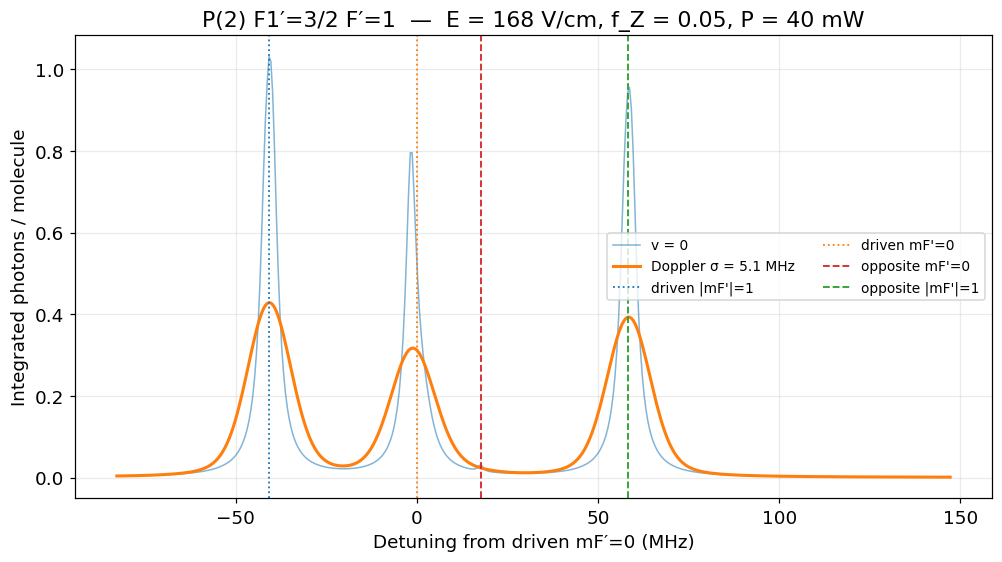

,centre (MHz),raw,Doppler
line,,,
driven |mF'|=1,-40.823217,1.031660,0.428429
driven mF'=0,0.000000,0.525605,0.311582
opposite mF'=0,17.591688,0.031129,0.023562
opposite |mF'|=1,58.388353,0.948480,0.392686


In [10]:
EXAMPLE_E_INDEX, EXAMPLE_Z_INDEX = 3, 3      # 168 V/cm, f_Z = 0.05

_example = build_model(EXAMPLE_E_INDEX, EXAMPLE_Z_INDEX)
_t0 = time.perf_counter()
_raw = photon_scan(_example, DETUNING_MHZ)[:, 0]
print(f"{DETUNING_MHZ.size} detunings in {time.perf_counter() - _t0:.1f} s")

_conv = gaussian_convolve_uniform_grid(DETUNING_MHZ, _raw, DOPPLER_SIGMA_MHZ)
# The scan ran on the delta grid; report it against the middle line.
_ex_centers = to_reference_frame(line_centers(_example))
_ex_detuning = DETUNING_MHZ - line_centers(_example)[REFERENCE_LINE]

fig, ax = plt.subplots(figsize=(9.0, 5.0), constrained_layout=True)
ax.plot(_ex_detuning, _raw, lw=1.0, alpha=0.55, label="v = 0")
ax.plot(_ex_detuning, _conv, lw=2.0, label=f"Doppler σ = {DOPPLER_SIGMA_MHZ:.1f} MHz")
for key in LINE_ORDER:
    ax.axvline(
        _ex_centers[key],
        color=LINE_COLORS[key],
        ls="--" if key[0] == "opposite" else ":",
        lw=1.2,
        label=LINE_LABELS[key],
    )
ax.set_xlabel("Detuning from driven mF′=0 (MHz)")
ax.set_ylabel("Integrated photons / molecule")
ax.set_title(
    f"P(2) F1′=3/2 F′=1  —  E = {_example.E_field:g} V/cm, "
    f"f_Z = {_example.z_fraction:g}, P = {POWER_MW:g} mW"
)
ax.grid(alpha=0.25)
ax.legend(fontsize=9, ncol=2)
plt.show()

pd.DataFrame(
    [
        {
            "line": LINE_LABELS[key],
            "centre (MHz)": _ex_centers[key],
            "raw": height_at(_ex_detuning, _raw, _ex_centers[key]),
            "Doppler": height_at(_ex_detuning, _conv, _ex_centers[key]),
        }
        for key in LINE_ORDER
    ]
).set_index("line")

## Main grid scan

10 electric fields × 7 polarization fractions = 70 OBE builds, each with a full detuning spectrum.
Results are cached; delete `_cache/` or bump `CACHE_VERSION` to force a recompute.

In [11]:
def run_main_grid() -> dict:
    photons = np.empty((E_FIELDS.size, Z_FRACTIONS.size, DETUNING_MHZ.size), dtype=float)
    centers = np.empty((E_FIELDS.size, len(LINE_ORDER)), dtype=float)
    rabis = np.empty((E_FIELDS.size, Z_FRACTIONS.size), dtype=float)
    couplings_arr = np.empty_like(rabis)

    wall = time.perf_counter()
    for ie in range(E_FIELDS.size):
        for iz in range(Z_FRACTIONS.size):
            model = build_model(ie, iz)
            photons[ie, iz] = photon_scan(model, DETUNING_MHZ)[:, 0]
            rabis[ie, iz] = model.rabi_for_power(POWER_W)
            couplings_arr[ie, iz] = model.main_coupling
            if iz == 0:
                centers[ie] = [line_centers(model)[k] for k in LINE_ORDER]
        print(f"  E = {E_FIELDS[ie]:6.1f} V/cm done  ({time.perf_counter() - wall:6.1f} s elapsed)")

    return {
        "cache_version": CACHE_VERSION,
        "photons": photons,
        # detuning_MHz and line_centers_MHz are stored in the delta frame (0 on driven |mF'|=1),
        # which is what the solver scanned. Reporting shifts them to the middle line.
        "detuning_frame": "driven |mF'|=1",
        "line_centers_MHz": centers,
        "rabi_rad_s": rabis,
        "main_couplings": couplings_arr,
        "detuning_MHz": DETUNING_MHZ,
        "E_fields": E_FIELDS,
        "z_fractions": Z_FRACTIONS,
        "line_labels": np.array([LINE_LABELS[k] for k in LINE_ORDER]),
        "power_W": POWER_W,
        "beam_wx": BEAM_WX,
        "beam_wy": BEAM_WY,
        "velocity": VELOCITY,
        "interaction_length": INTERACTION_LENGTH,
        "t_end": T_END,
        "B_field": B_FIELD,
        "initial_weights": INITIAL_WEIGHTS,
        "Jmax_X": JMAX_X,
        "Jmax_B": JMAX_B,
        "gamma": float(GAMMA),
        "doppler_sigma_MHz": DOPPLER_SIGMA_MHZ,
        "solver": SOLVER,
        "execution_mode": EXECUTION_MODE,
        "solver_dt": SOLVER_DT,
        "reltol": SOLVER_RELTOL,
        "abstol": SOLVER_ABSTOL,
        "wall_s": time.perf_counter() - wall,
    }


if MAIN_CACHE.exists():
    with np.load(MAIN_CACHE, allow_pickle=False) as handle:
        main = {k: handle[k] for k in handle.files}
    if int(main["cache_version"]) != CACHE_VERSION:
        raise ValueError(f"cache version mismatch in {MAIN_CACHE}")
    print(f"loaded cache {MAIN_CACHE}  (wall {float(main['wall_s']):.0f} s when built)")
else:
    print(f"no cache at {MAIN_CACHE} — running {E_FIELDS.size * Z_FRACTIONS.size} builds")
    main = run_main_grid()
    np.savez_compressed(MAIN_CACHE, **main)
    print(f"saved {MAIN_CACHE}  ({main['wall_s']:.0f} s)")

photons_raw = main["photons"]
photons_conv = convolve_spectrum(main["detuning_MHz"], photons_raw.transpose(2, 0, 1)).transpose(1, 2, 0)
detuning = main["detuning_MHz"]          # delta frame

# Reported axes: shift each field so the middle of the three peaks sits at 0. The shift is
# field-dependent, so every field gets its own x array.
REF_INDEX = LINE_ORDER.index(REFERENCE_LINE)
shift_per_field = main["line_centers_MHz"][:, REF_INDEX].astype(float)
centers_ref = main["line_centers_MHz"] - shift_per_field[:, None]
detuning_ref = detuning[None, :] - shift_per_field[:, None]
# Window common to every field, for panels that share an x axis.
REF_XLIM = (float(detuning_ref[:, 0].max()), float(detuning_ref[:, -1].min()))

print("photons array:", photons_raw.shape)
print(f"reported detuning window common to all fields: "
      f"{REF_XLIM[0]:.1f} … {REF_XLIM[1]:.1f} MHz (0 = driven mF′=0)")

loaded cache C:\Users\ogras\Documents\GitHub\CeNTREX-TlF\examples\lindblad\_cache\p2_f1_3o2_f1_mf_scan_E150-250_fz0-0.3_40mW_2x1.5cm_v3.npz  (wall 4746 s when built)
photons array: (10, 7, 461)
reported detuning window common to all fields: -77.7 … 123.6 MHz (0 = driven mF′=0)


## Simulated spectra

In [12]:
print(f"grid: {main['E_fields'].size} fields × {main['z_fractions'].size} polarizations")
print(f"detuning: {detuning[0]:.1f} … {detuning[-1]:.1f} MHz, {detuning.size} points")
print(f"Rabi at {POWER_MW:g} mW: "
      f"{main['rabi_rad_s'].min() / (2 * np.pi * 1e6):.4f}"
      f" … {main['rabi_rad_s'].max() / (2 * np.pi * 1e6):.4f} MHz")

grid: 10 fields × 7 polarizations
detuning: -42.0 … 188.0 MHz, 461 points
Rabi at 40 mW: 0.0814 … 0.1201 MHz


## Plots

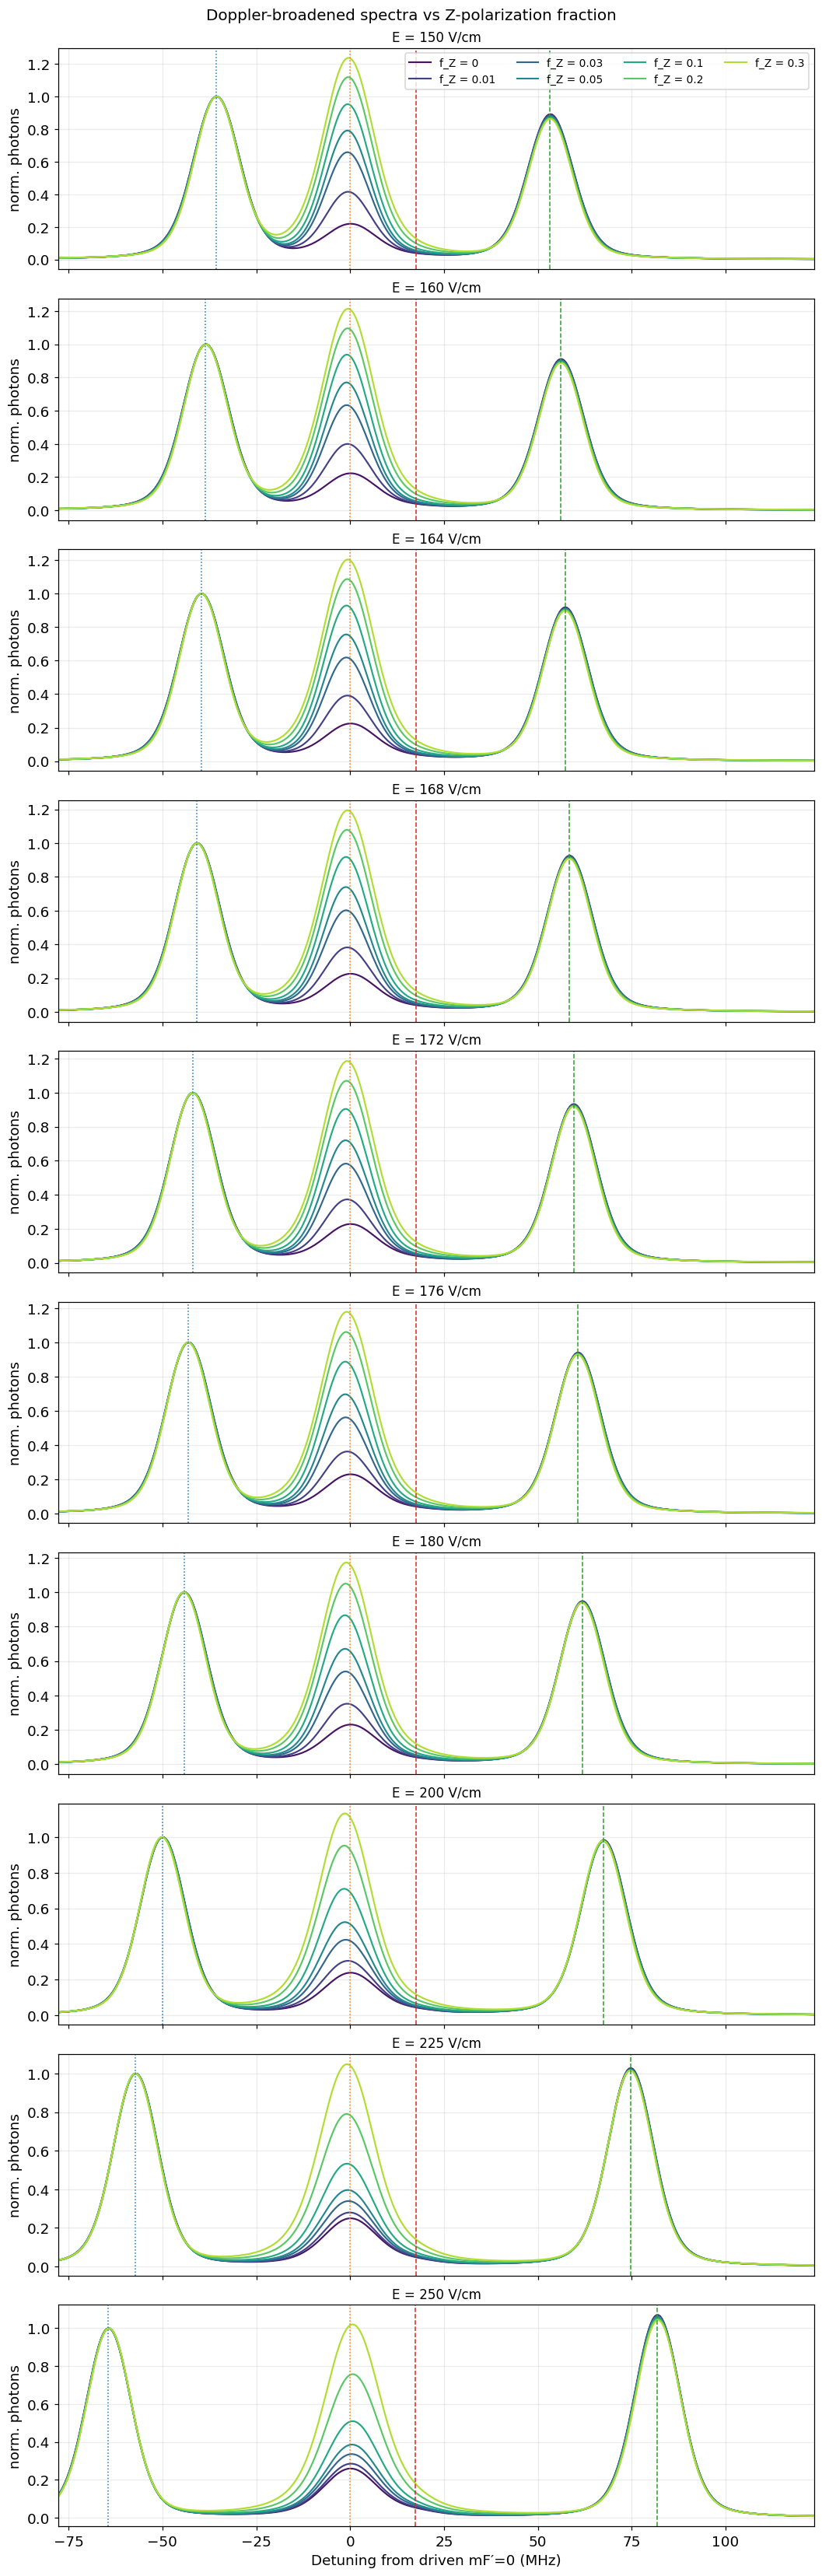

In [13]:
# Spectra vs f_Z at each field, normalized to the driven |mF'|=1 peak.
FZ_COLORS = plt.cm.viridis(np.linspace(0.05, 0.88, main["z_fractions"].size))
fig, axes = plt.subplots(
    len(main["E_fields"]), 1, figsize=(9.5, 3.0 * len(main["E_fields"])),
    sharex=True, constrained_layout=True,
)
for ie, E in enumerate(main["E_fields"]):
    ax = axes[ie]
    centers = {k: float(centers_ref[ie, j]) for j, k in enumerate(LINE_ORDER)}
    for iz, fz in enumerate(main["z_fractions"]):
        spectrum = photons_conv[ie, iz]
        norm = height_at(detuning_ref[ie], spectrum, centers[("driven", 1)])
        # f_Z is an ordered quantity, so it gets a sequential ramp, not a categorical cycle.
        ax.plot(detuning_ref[ie], spectrum / norm, lw=1.4, color=FZ_COLORS[iz],
                label=f"f_Z = {fz:g}")
    for key in LINE_ORDER:
        ax.axvline(centers[key], color=LINE_COLORS[key],
                   ls="--" if key[0] == "opposite" else ":", lw=1.0)
    ax.set_ylabel("norm. photons")
    ax.set_xlim(*REF_XLIM)
    ax.set_title(f"E = {E:g} V/cm", fontsize=11)
    ax.grid(alpha=0.25)
    if ie == 0:
        ax.legend(fontsize=9, ncol=4)
axes[-1].set_xlabel("Detuning from driven mF′=0 (MHz)")
fig.suptitle("Doppler-broadened spectra vs Z-polarization fraction", fontsize=13)
fig.savefig(FIGURE_DIR / "spectra_vs_fz.png", dpi=200, bbox_inches="tight")
plt.show()

## Comparison with experimental data

The measured spectrum is compared to the simulation **as a whole curve** — no peak extraction.
Two nuisance parameters are unavoidable and are profiled out at every grid point:

- **the frequency origin**, since the absolute laser frequency zero is not known; and
- **an overall amplitude scale**, since the measurement is in detector units, not
  photons per molecule.

The amplitude scale is linear, so at each trial origin it is solved for in closed form by
weighted least squares. The origin is scanned on a grid. What is left is a χ² per `(E, f_Z)`
point, which is the thing to look at.

Set `DATA_CSV` below to point at the measurement. The expected format matches
`digitized_det1_nltl_scan.csv`: columns `frequency_MHz`, `y`, `sy`. `DATA_FREQ_TO_UV` converts the
data frequency axis into UV detuning — it is `-4.0` for a digitized IR axis on a quadrupled laser,
and `1.0` if the data is already UV detuning in MHz. **Check this against how your file was
recorded**; it sets both the scale and the sign of the frequency axis.

If `DATA_CSV` is `None` the section is skipped and the notebook still produces all simulated
spectra.

In [14]:
DATA_CSV: Path | None = CACHE_DIR.parent / "P2_F1_3_2_F_1_frequency_scan_freq_y_sy.csv"
DATA_FREQ_COLUMN = "freq_MHz"
DATA_Y_COLUMN = "y"
DATA_SY_COLUMN = "sy"                 # set to None if the file has no uncertainty column
# The measured axis is an *inverted IR* frequency on a quadrupled laser, so the UV
# detuning is -4x the IR offset. Corroborated by the peak spacings: the observed 15
# and 10 MHz splittings become 60 and 40 MHz in the UV, matching the computed line
# pattern to a few MHz, whereas +4 and +/-1 do not match at any field.
DATA_FREQ_TO_UV = -4.0                # UV detuning = DATA_FREQ_TO_UV * (f - f_zero)
DATA_SUBTRACT_BASELINE = True         # fit a constant offset alongside the amplitude
# Trial frequency origins. The grid spans ~115 MHz of IR, so 4001 points is a 0.115 MHz UV
# step -- roughly a tenth of the 1.56 MHz natural linewidth. Coarser sampling quantizes the
# fitted origin badly enough that the reported chi2 depends on where the detuning axis happens
# to be zeroed, which it must not: 401 points (1.15 MHz UV) gave 2.09 or 2.59 for the same fit
# depending on the frame.
ORIGIN_GRID_POINTS = 4001
MIN_OVERLAP_FRACTION = 0.8            # reject origins that push data off the simulated window


def load_experimental_data(path: Path) -> dict[str, np.ndarray]:
    frame = pd.read_csv(path)
    x = frame[DATA_FREQ_COLUMN].to_numpy(dtype=float)
    y = frame[DATA_Y_COLUMN].to_numpy(dtype=float)
    if DATA_SY_COLUMN and DATA_SY_COLUMN in frame.columns:
        sy = frame[DATA_SY_COLUMN].to_numpy(dtype=float)
        sy = np.where(sy > 0, sy, np.nanmedian(sy[sy > 0]) if np.any(sy > 0) else 1.0)
    else:
        sy = np.ones_like(y)
    return {"x": x, "y": y, "sy": sy}


def compare_to_data(
    detuning_MHz: np.ndarray,
    model: np.ndarray,
    data: dict[str, np.ndarray],
    origin_grid: np.ndarray,
) -> dict:
    """Best chi-square over the frequency origin, with amplitude (and baseline) profiled out."""
    best = {"chi2": np.inf, "origin_MHz": np.nan, "scale": np.nan, "baseline": 0.0}
    x, y, sy = data["x"], data["y"], data["sy"]
    weight = 1.0 / sy**2

    for origin in origin_grid:
        uv = DATA_FREQ_TO_UV * (x - origin)
        m = np.interp(uv, detuning_MHz, model, left=np.nan, right=np.nan)
        ok = np.isfinite(m)
        if np.count_nonzero(ok) < MIN_OVERLAP_FRACTION * x.size:
            continue

        w, mi, yi = weight[ok], m[ok], y[ok]
        if DATA_SUBTRACT_BASELINE:
            # Solve [scale, baseline] by weighted linear least squares.
            design = np.column_stack([mi, np.ones_like(mi)])
            wd = design * w[:, None]
            try:
                scale, baseline = np.linalg.solve(design.T @ wd, wd.T @ yi)
            except np.linalg.LinAlgError:
                continue
        else:
            denom = np.sum(w * mi * mi)
            if denom <= 0:
                continue
            scale, baseline = np.sum(w * mi * yi) / denom, 0.0

        chi2 = float(np.sum(w * (yi - (scale * mi + baseline)) ** 2))
        if chi2 < best["chi2"]:
            best = {"chi2": chi2, "origin_MHz": float(origin),
                    "scale": float(scale), "baseline": float(baseline),
                    "n_points": int(np.count_nonzero(ok))}
    return best


if DATA_CSV is None or not Path(DATA_CSV).exists():
    data = None
    print("DATA_CSV is not set or not found — set it to your measured P(2) scan.")
else:
    data = load_experimental_data(Path(DATA_CSV))
    span = detuning[-1] - detuning[0]
    centre = np.mean(data["x"])
    origin_grid = np.linspace(
        centre - abs(span / DATA_FREQ_TO_UV), centre + abs(span / DATA_FREQ_TO_UV),
        ORIGIN_GRID_POINTS,
    )
    print(f"loaded {data['x'].size} data points from {Path(DATA_CSV).name}")
    print(f"data frequency range: {data['x'].min():.1f} … {data['x'].max():.1f} MHz (inverted IR)")
    print(f"scanning {ORIGIN_GRID_POINTS} trial origins over "
          f"{origin_grid[0]:.1f} … {origin_grid[-1]:.1f} MHz")

loaded 43 data points from P2_F1_3_2_F_1_frequency_scan_freq_y_sy.csv
data frequency range: 1656.0 … 1707.0 MHz (inverted IR)
scanning 4001 trial origins over 1624.6 … 1739.6 MHz


best match:
  E   = 168 V/cm
  f_Z = 0.05
  reduced chi2 = 2.090  (chi2 = 81.5, 42 points, dof = 39)


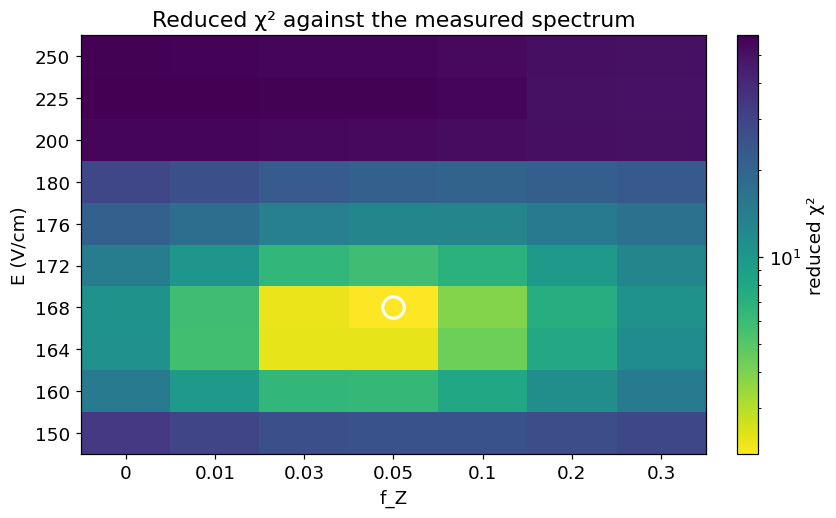

,E_V_per_cm,f_Z,chi2,origin_MHz,scale,baseline,n_points,dof,reduced_chi2
24,168.0,0.05,81.5172,1684.5368,173.6071,-2.0620,42,39,2.0902
23,168.0,0.03,89.5380,1684.5080,182.0271,-1.8695,42,39,2.2958
16,164.0,0.03,89.9238,1684.5655,180.1539,-1.8266,41,38,2.3664
17,164.0,0.05,90.0030,1684.5655,171.4591,-1.9434,41,38,2.3685
25,168.0,0.10,150.9157,1684.5368,157.8480,-1.8189,42,39,3.8696
18,164.0,0.10,165.1511,1684.5655,155.2509,-1.6213,41,38,4.3461
15,164.0,0.01,218.2281,1684.5655,183.7824,-0.6948,41,38,5.7428
22,168.0,0.01,225.0287,1684.5080,184.7497,-0.7366,42,39,5.7700
31,172.0,0.05,225.7316,1684.4793,167.0456,-1.4080,42,39,5.7880
10,160.0,0.05,240.2650,1684.6230,161.5809,-1.2830,41,38,6.3228


In [15]:
if data is not None:
    chi2_grid = np.full((main["E_fields"].size, main["z_fractions"].size), np.nan)
    fit_records = []
    for ie in range(main["E_fields"].size):
        for iz in range(main["z_fractions"].size):
            fit = compare_to_data(detuning_ref[ie], photons_conv[ie, iz], data, origin_grid)
            chi2_grid[ie, iz] = fit["chi2"]
            fit_records.append({"E_V_per_cm": float(main["E_fields"][ie]),
                                "f_Z": float(main["z_fractions"][iz]), **fit})
    fits = pd.DataFrame(fit_records)
    # Degrees of freedom use the points actually inside the simulated window at the
    # best origin, not the full file, and subtract the profiled nuisance parameters.
    n_par = 3 if DATA_SUBTRACT_BASELINE else 2
    fits["dof"] = (fits["n_points"] - n_par).clip(lower=1)
    fits["reduced_chi2"] = fits["chi2"] / fits["dof"]

    best = fits.loc[fits["chi2"].idxmin()]
    print("best match:")
    print(f"  E   = {best['E_V_per_cm']:g} V/cm")
    print(f"  f_Z = {best['f_Z']:g}")
    print(f"  reduced chi2 = {best['reduced_chi2']:.3f}  "
          f"(chi2 = {best['chi2']:.1f}, {int(best['n_points'])} points, dof = {int(best['dof'])})")

    fig, ax = plt.subplots(figsize=(7.5, 4.6), constrained_layout=True)
    reduced_grid = (
        fits.pivot(index="E_V_per_cm", columns="f_Z", values="reduced_chi2")
        .reindex(index=main["E_fields"], columns=main["z_fractions"]).to_numpy()
    )
    # Reduced chi2 spans more than an order of magnitude across the grid; a log scale
    # keeps the minimum readable instead of saturating everything near it.
    im = ax.imshow(reduced_grid, origin="lower", aspect="auto", cmap="viridis_r",
                   norm=LogNorm(vmin=np.nanmin(reduced_grid), vmax=np.nanmax(reduced_grid)))
    ax.set_xticks(range(main["z_fractions"].size))
    ax.set_xticklabels([f"{v:g}" for v in main["z_fractions"]])
    ax.set_yticks(range(main["E_fields"].size))
    ax.set_yticklabels([f"{v:g}" for v in main["E_fields"]])
    ax.set_xlabel("f_Z")
    ax.set_ylabel("E (V/cm)")
    ax.set_title("Reduced χ² against the measured spectrum")
    ax.plot(
        int(np.argmin(np.abs(main["z_fractions"] - best["f_Z"]))),
        int(np.argmin(np.abs(main["E_fields"] - best["E_V_per_cm"]))),
        "o", mfc="none", mec="w", ms=14, mew=2,
    )
    fig.colorbar(im, ax=ax, label="reduced χ²")
    fig.savefig(FIGURE_DIR / "chi2_map.png", dpi=200, bbox_inches="tight")
    plt.show()
    display(fits.sort_values("chi2").head(10).round(4))

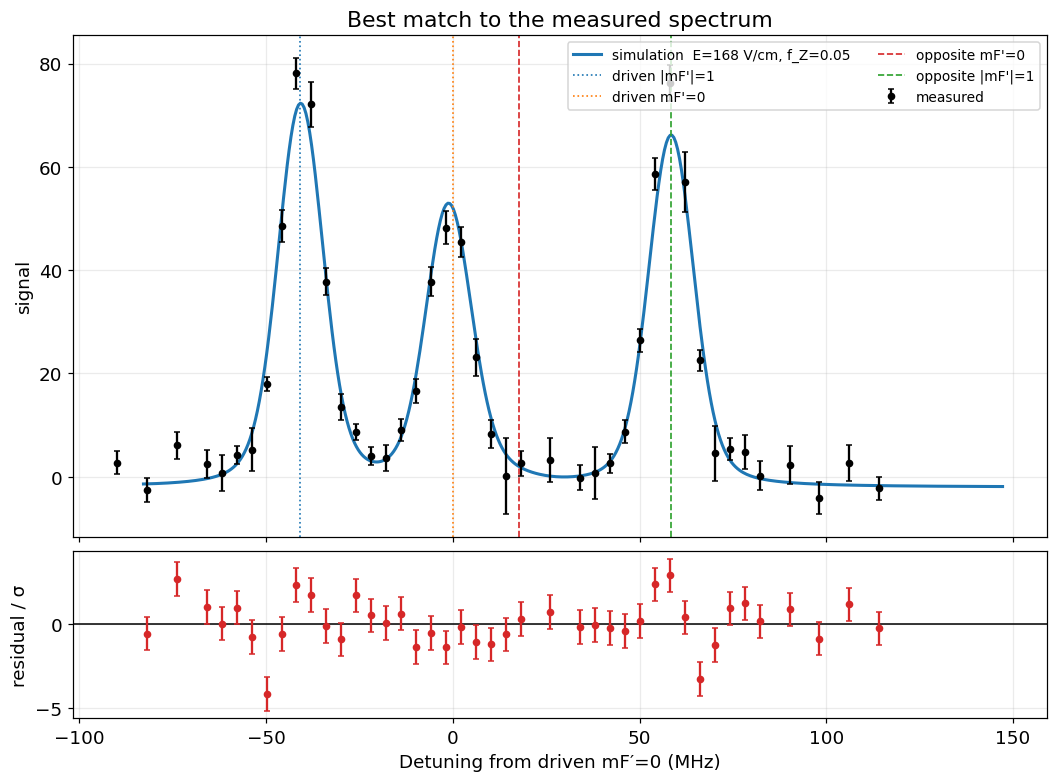

In [16]:
if data is not None:
    ie = int(np.argmin(np.abs(main["E_fields"] - best["E_V_per_cm"])))
    iz = int(np.argmin(np.abs(main["z_fractions"] - best["f_Z"])))
    model = photons_conv[ie, iz]
    model_detuning = detuning_ref[ie]
    uv_data = DATA_FREQ_TO_UV * (data["x"] - best["origin_MHz"])

    fig, axes = plt.subplots(2, 1, figsize=(9.5, 7.0), sharex=True,
                             gridspec_kw={"height_ratios": [3, 1]}, constrained_layout=True)

    axes[0].plot(model_detuning, best["scale"] * model + best["baseline"], lw=2.0,
                 label=f"simulation  E={best['E_V_per_cm']:g} V/cm, f_Z={best['f_Z']:g}")
    axes[0].errorbar(uv_data, data["y"], yerr=data["sy"], fmt="o", ms=4, capsize=2,
                     color="k", label="measured")
    centers = {k: float(centers_ref[ie, j]) for j, k in enumerate(LINE_ORDER)}
    for key in LINE_ORDER:
        axes[0].axvline(centers[key], color=LINE_COLORS[key],
                        ls="--" if key[0] == "opposite" else ":", lw=1.1,
                        label=LINE_LABELS[key])
    axes[0].set_ylabel("signal")
    axes[0].set_title("Best match to the measured spectrum")
    axes[0].grid(alpha=0.25)
    axes[0].legend(fontsize=9, ncol=2)

    interp = np.interp(uv_data, model_detuning, model, left=np.nan, right=np.nan)
    residual = (data["y"] - (best["scale"] * interp + best["baseline"])) / data["sy"]
    axes[1].axhline(0, color="k", lw=1)
    axes[1].errorbar(uv_data, residual, yerr=1.0, fmt="o", ms=4, capsize=2, color="tab:red")
    axes[1].set_xlabel("Detuning from driven mF′=0 (MHz)")
    axes[1].set_ylabel("residual / σ")
    axes[1].grid(alpha=0.25)
    fig.savefig(FIGURE_DIR / "best_fit_overlay.png", dpi=200, bbox_inches="tight")
    plt.show()

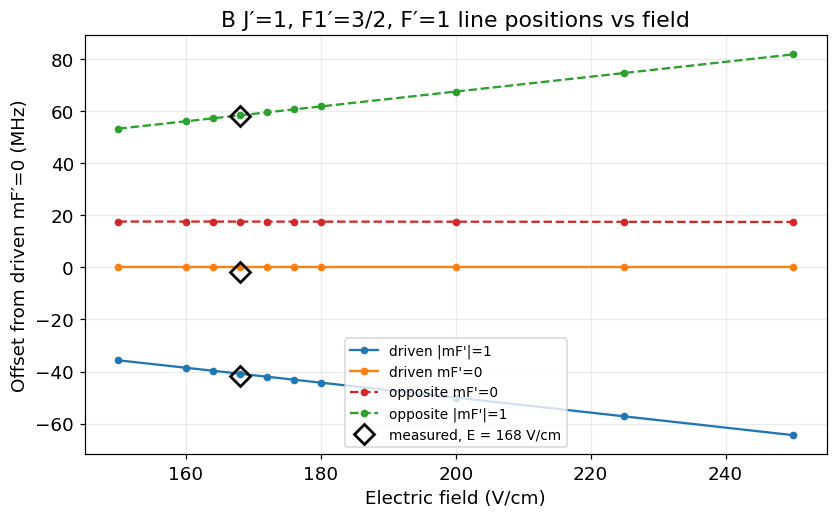

In [17]:
# Report figure: line positions vs field, with the measured peaks at the fitted field.
# The three visible peaks of the measured scan, read off the raw IR axis (see the report).
MEASURED_PEAKS_IR_MHZ = np.array([1695.0, 1685.0, 1670.0])

fig, ax = plt.subplots(figsize=(7.5, 4.6), constrained_layout=True)
for key in LINE_ORDER:
    ax.plot(
        E_FIELDS,
        [_centers_ref[E][key] for E in E_FIELDS],
        marker="o",
        ms=4,
        color=LINE_COLORS[key],
        ls="--" if key[0] == "opposite" else "-",
        label=LINE_LABELS[key],
    )
if data is not None:
    measured_uv = DATA_FREQ_TO_UV * (MEASURED_PEAKS_IR_MHZ - best["origin_MHz"])
    ax.plot(
        np.full(measured_uv.size, float(best["E_V_per_cm"])),
        measured_uv,
        "D", color="k", ms=9, mfc="none", mew=1.8,
        label=f"measured, E = {best['E_V_per_cm']:g} V/cm",
    )
ax.set_xlabel("Electric field (V/cm)")
ax.set_ylabel("Offset from driven mF′=0 (MHz)")
ax.set_title("B J′=1, F1′=3/2, F′=1 line positions vs field")
ax.grid(alpha=0.25)
ax.legend(fontsize=9)
fig.savefig(FIGURE_DIR / "line_positions_vs_field.png", dpi=200, bbox_inches="tight")
plt.show()


## Where the mF′=0 line comes from

The mF′=0 line has appreciable strength **even at pure X̂ polarization**, which looks wrong at
first: X̂ = (σ⁻ − σ⁺)/√2 drives ΔmF = ±1 only, so from an mF=0 ground state it can reach mF′=±1
and nothing else.

The resolution is the initial population, not the polarization. Of the four lens-focused levels,
the two F=3, mF=±1 triplet components carry **2/9 ≈ 0.22** of the population, and for them
ΔmF = ±1 leads to mF′=0 or mF′=±2 — and F′=1 has no mF′=±2. So the mF=±1 population feeds the
mF′=0 line and essentially nothing else, while the mF=0 population feeds only the |mF′|=1 lines.
The two are almost perfectly complementary, as the table below shows.

**Consequence for reading `f_Z`.** The mF′=0 line height is fed by *both* Ẑ polarization and
mF=±1 population, and the two are not separable from that line alone. Any `f_Z` inferred here is
therefore conditional on the assumed triplet distribution (an even 1/3 : 1/3 : 1/3 spread over
mF = 0, ±1). If the real mF=±1 fraction is larger, the fitted `f_Z` is correspondingly
overestimated — treat it as an upper bound unless the mF distribution is known independently.


In [18]:
# Complementarity of mF=0 and mF=+/-1 population at pure X polarization.
DIAG_E = float(best["E_V_per_cm"]) if data is not None else 168.0
diag_model = build_model(int(np.argmin(np.abs(E_FIELDS - DIAG_E))), 0)   # z_index 0 -> f_Z = 0
diag_centers = line_centers(diag_model)
diag_detuning = np.array([diag_centers[k] for k in LINE_ORDER])
diag_rabi = diag_model.rabi_for_power(POWER_W)


def rho_from_levels(spec: dict[tuple[int, int], float]) -> np.ndarray:
    """Density matrix from {(F, mF): weight} within X J=2, F1=5/2."""
    rho = np.zeros((len(diag_model.system.QN),) * 2, dtype=np.complex128)
    for (F, mF), w in spec.items():
        selector = states.QuantumSelector(
            electronic=states.ElectronicState.X, J=2, F1=5 / 2, F=F, mF=mF
        )
        idx = int(np.asarray(selector.get_indices(diag_model.system.QN), dtype=int).ravel()[0])
        rho[idx, idx] = w
    return rho / np.trace(rho)


DIAG_CASES = {
    "full (2/3 singlet + 1/3 triplet)": {(2, 0): 2 / 3, (3, -1): 1 / 9, (3, 0): 1 / 9, (3, 1): 1 / 9},
    "mF = 0 only": {(2, 0): 2 / 3, (3, 0): 1 / 9},
    "mF = +/-1 only": {(3, -1): 0.5, (3, 1): 0.5},
}

diag_rows = []
for name, spec in DIAG_CASES.items():
    result = lindblad.grid_scan(
        diag_model.prepared, rho_from_levels(spec), (0.0, T_END),
        scan={"detuning": 2 * np.pi * 1e6 * diag_detuning, "rabi": np.array([diag_rabi])},
        solver=SOLVER, execution_mode=EXECUTION_MODE, output="photon_integral",
        output_when="final", integral_weights=diag_model.photon_weights,
        dt=SOLVER_DT, reltol=SOLVER_RELTOL, abstol=SOLVER_ABSTOL,
        parallel=True, dense_output=False,
    )
    v = np.asarray(result.values).reshape(len(LINE_ORDER)).real
    diag_rows.append({"initial population": name,
                      **{LINE_LABELS[k]: v[j] for j, k in enumerate(LINE_ORDER)},
                      "mF'=0 / |mF'|=1": v[1] / v[0]})

print(f"pure X polarization (f_Z = 0), E = {diag_model.E_field:g} V/cm, {POWER_MW:g} mW")
print(f"fraction of the full initial population in mF = +/-1: {2 / 9:.3f}")
display(pd.DataFrame(diag_rows).set_index("initial population").round(4))


pure X polarization (f_Z = 0), E = 168 V/cm, 40 mW
fraction of the full initial population in mF = +/-1: 0.222


,driven |mF'|=1,driven mF'=0,opposite mF'=0,opposite |mF'|=1,mF'=0 / |mF'|=1
initial population,,,,,
full (2/3 singlet + 1/3 triplet),0.9146,0.1388,0.0262,0.8749,0.1518
mF = 0 only,1.1740,0.0055,0.0052,1.1239,0.0047
mF = +/-1 only,0.0067,0.6052,0.0997,0.0033,90.7773


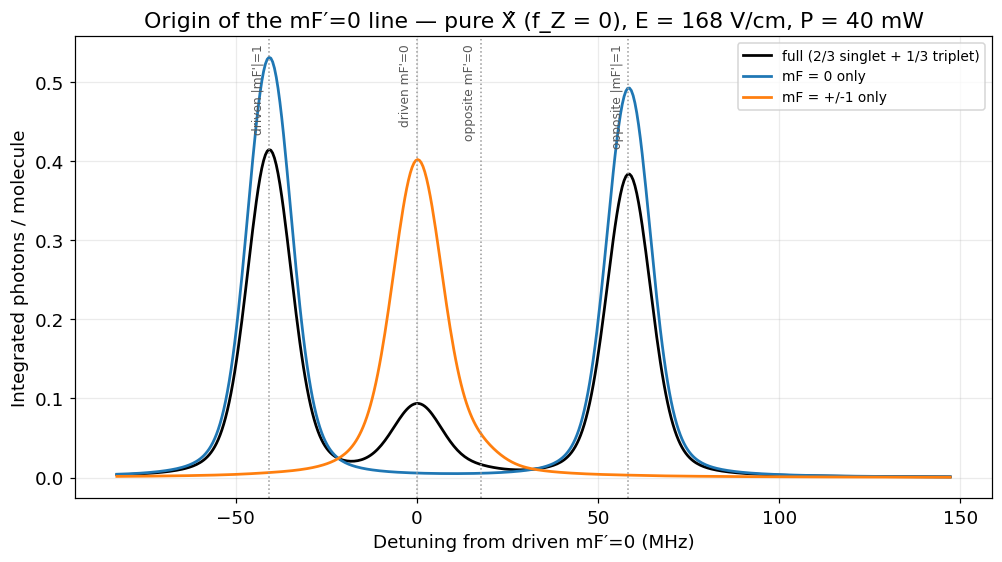

In [19]:
# Report figure: full spectra for the three initial populations at pure X polarization.
diag_spectra = {}
for name, spec in DIAG_CASES.items():
    result = lindblad.grid_scan(
        diag_model.prepared, rho_from_levels(spec), (0.0, T_END),
        scan={"detuning": 2 * np.pi * 1e6 * DETUNING_MHZ, "rabi": np.array([diag_rabi])},
        solver=SOLVER, execution_mode=EXECUTION_MODE, output="photon_integral",
        output_when="final", integral_weights=diag_model.photon_weights,
        dt=SOLVER_DT, reltol=SOLVER_RELTOL, abstol=SOLVER_ABSTOL,
        parallel=True, threads=SCAN_THREADS, dense_output=False,
    )
    raw = np.asarray(result.values).reshape(DETUNING_MHZ.size).real
    diag_spectra[name] = gaussian_convolve_uniform_grid(DETUNING_MHZ, raw, DOPPLER_SIGMA_MHZ)

# Colour encodes the initial population here, not parity, so the line markers are neutral.
DIAG_COLORS = {
    "full (2/3 singlet + 1/3 triplet)": "k",
    "mF = 0 only": "tab:blue",
    "mF = +/-1 only": "tab:orange",
}

# diag_centers / DETUNING_MHZ are delta frame (they drive the solver); report the shifted axis.
diag_centers_ref = to_reference_frame(diag_centers)
diag_detuning_ref = DETUNING_MHZ - diag_centers[REFERENCE_LINE]

fig, ax = plt.subplots(figsize=(9.0, 5.0), constrained_layout=True)
for name, spectrum in diag_spectra.items():
    ax.plot(diag_detuning_ref, spectrum, lw=1.8, color=DIAG_COLORS[name], label=name)
for key in LINE_ORDER:
    ax.axvline(diag_centers_ref[key], color="0.6", ls=":", lw=1.0)
    ax.annotate(LINE_LABELS[key], (diag_centers_ref[key], 0.985), xycoords=("data", "axes fraction"),
                xytext=(-3, 0), textcoords="offset points",
                rotation=90, fontsize=8, color="0.35", ha="right", va="top")
ax.set_xlabel("Detuning from driven mF′=0 (MHz)")
ax.set_ylabel("Integrated photons / molecule")
ax.set_title(
    f"Origin of the mF′=0 line — pure X̂ (f_Z = 0), E = {diag_model.E_field:g} V/cm, "
    f"P = {POWER_MW:g} mW"
)
ax.grid(alpha=0.25)
ax.legend(fontsize=9)
fig.savefig(FIGURE_DIR / "mf0_origin.png", dpi=200, bbox_inches="tight")
plt.show()


## Power axis

The R(2) analysis found the peak ratios depended strongly on optical power, so the same axis is
scanned here on a 3 × 3 subset of the grid. Power is a runtime parameter, so all powers go into a
single `grid_scan` without rebuilding the OBE system.

In [20]:
POWER_DETUNING_MHZ = common_detuning_grid(POWER_SCAN_DETUNING_STEP_MHZ)
POWER_SCAN_W = POWER_SCAN_MW * 1e-3
_e_idx = [int(np.argmin(np.abs(E_FIELDS - E))) for E in POWER_SCAN_E_FIELDS]
_z_idx = [int(np.argmin(np.abs(Z_FRACTIONS - f))) for f in POWER_SCAN_Z_FRACTIONS]


def run_power_grid() -> dict:
    shape = (len(_e_idx), len(_z_idx), POWER_DETUNING_MHZ.size, POWER_SCAN_W.size)
    photons = np.empty(shape, dtype=float)
    wall = time.perf_counter()
    for a, ie in enumerate(_e_idx):
        for b, iz in enumerate(_z_idx):
            model = build_model(ie, iz)
            photons[a, b] = photon_scan(model, POWER_DETUNING_MHZ, POWER_SCAN_W)
        print(f"  E = {E_FIELDS[ie]:6.1f} V/cm done  ({time.perf_counter() - wall:6.1f} s elapsed)")
    return {
        "cache_version": POWER_CACHE_VERSION,
        "photons": photons,
        "detuning_MHz": POWER_DETUNING_MHZ,
        "powers_W": POWER_SCAN_W,
        "beam_wx": BEAM_WX,
        "beam_wy": BEAM_WY,
        "velocity": VELOCITY,
        "t_end": T_END,
        "E_fields": E_FIELDS[_e_idx],
        "z_fractions": Z_FRACTIONS[_z_idx],
        "line_centers_MHz": main["line_centers_MHz"][_e_idx],
        "doppler_sigma_MHz": DOPPLER_SIGMA_MHZ,
        "Jmax_X": JMAX_X,
        "Jmax_B": JMAX_B,
        "solver": SOLVER,
        "solver_dt": SOLVER_DT,
        "reltol": SOLVER_RELTOL,
        "abstol": SOLVER_ABSTOL,
        "wall_s": time.perf_counter() - wall,
    }


if POWER_CACHE.exists():
    with np.load(POWER_CACHE, allow_pickle=False) as handle:
        power = {k: handle[k] for k in handle.files}
    if int(power["cache_version"]) != POWER_CACHE_VERSION:
        raise ValueError(f"cache version mismatch in {POWER_CACHE}")
    print(f"loaded cache {POWER_CACHE}  (wall {float(power['wall_s']):.0f} s when built)")
else:
    print(f"no cache at {POWER_CACHE} — running {len(_e_idx) * len(_z_idx)} builds "
          f"× {POWER_SCAN_W.size} powers")
    power = run_power_grid()
    np.savez_compressed(POWER_CACHE, **power)
    print(f"saved {POWER_CACHE}  ({power['wall_s']:.0f} s)")

power_conv = convolve_spectrum(power["detuning_MHz"], power["photons"].transpose(2, 0, 1, 3)).transpose(1, 2, 0, 3)

# Same reporting shift as the main grid, on the power subset's own fields.
power_shift = power["line_centers_MHz"][:, REF_INDEX].astype(float)
power_centers_ref = power["line_centers_MHz"] - power_shift[:, None]
power_detuning_ref = power["detuning_MHz"][None, :] - power_shift[:, None]
POWER_REF_XLIM = (float(power_detuning_ref[:, 0].max()), float(power_detuning_ref[:, -1].min()))

print("power photons array:", power["photons"].shape)

loaded cache C:\Users\ogras\Documents\GitHub\CeNTREX-TlF\examples\lindblad\_cache\p2_f1_3o2_f1_power_scan_2x1.5cm_v2.npz  (wall 1488 s when built)
power photons array: (3, 3, 231, 5)


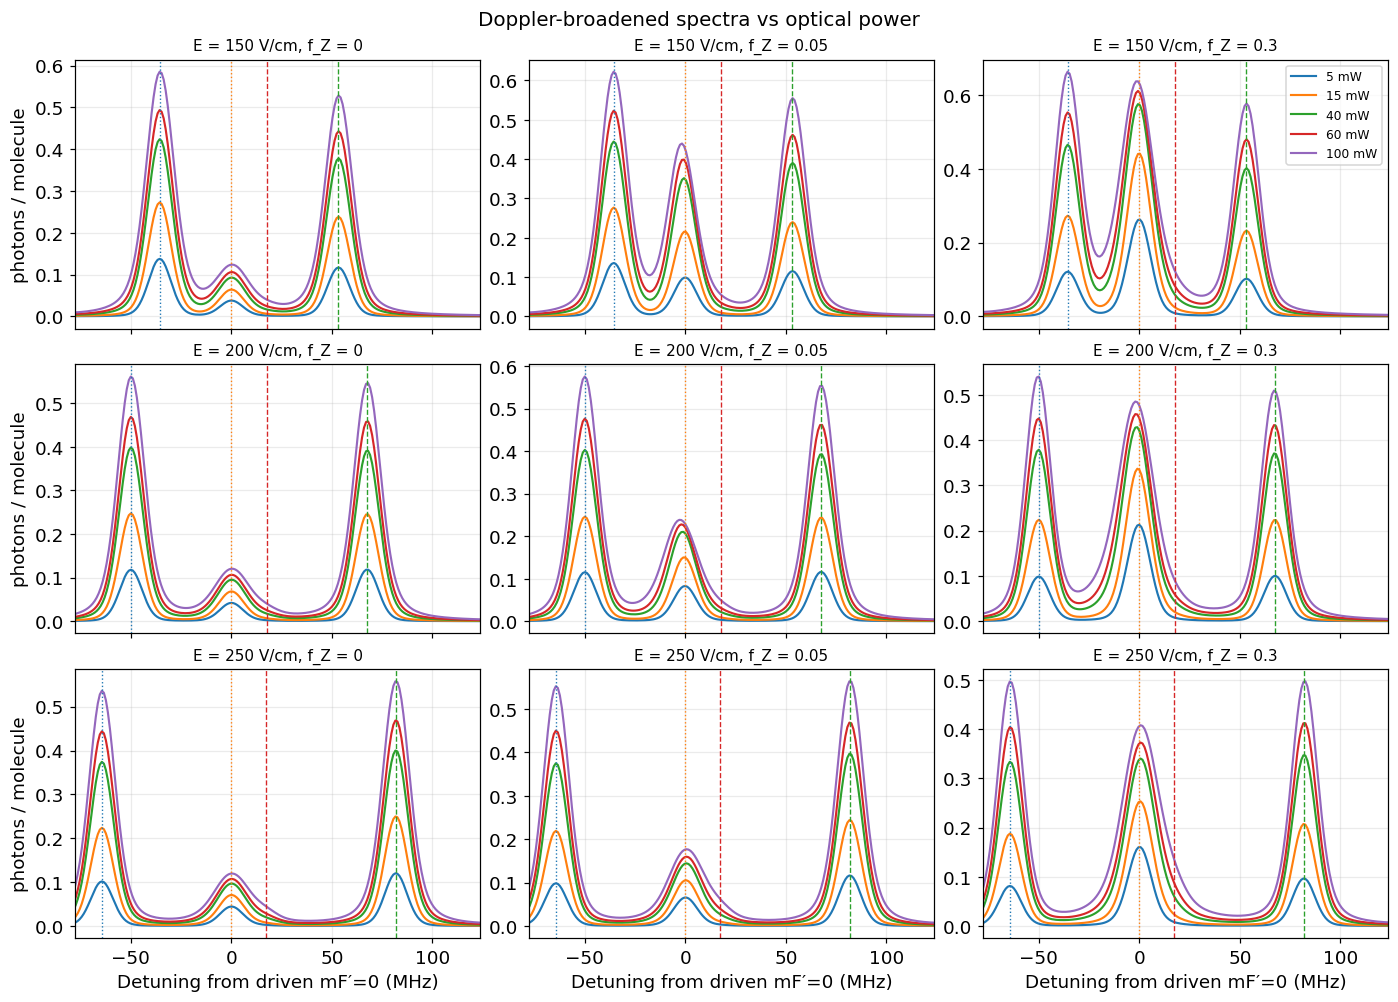

In [21]:
# Spectra vs power, one panel per (E, f_Z) in the subset.
n_rows, n_cols = power["E_fields"].size, power["z_fractions"].size
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.0 * n_rows),
                         sharex=True, constrained_layout=True, squeeze=False)
for a, E in enumerate(power["E_fields"]):
    centers = {k: float(power_centers_ref[a, j]) for j, k in enumerate(LINE_ORDER)}
    for b, fz in enumerate(power["z_fractions"]):
        ax = axes[a][b]
        for c, p_w in enumerate(power["powers_W"]):
            ax.plot(power_detuning_ref[a], power_conv[a, b, :, c], lw=1.4,
                    label=f"{p_w * 1e3:g} mW")
        for key in LINE_ORDER:
            ax.axvline(centers[key], color=LINE_COLORS[key],
                       ls="--" if key[0] == "opposite" else ":", lw=0.9)
        ax.set_title(f"E = {E:g} V/cm, f_Z = {fz:g}", fontsize=10)
        ax.set_xlim(*POWER_REF_XLIM)
        ax.grid(alpha=0.25)
        if b == 0:
            ax.set_ylabel("photons / molecule")
        if a == n_rows - 1:
            ax.set_xlabel("Detuning from driven mF′=0 (MHz)")
axes[0][-1].legend(fontsize=8)
fig.suptitle("Doppler-broadened spectra vs optical power", fontsize=13)
plt.show()

## How to use this against the data

Comparison is done on the full spectrum. Two features carry most of the information, and they
are close to independent:

1. **Line spacings fix the electric field.** The four line *positions* depend only on E, not on
   polarization or power — see the "line positions vs field" plot. The driven-to-opposite
   |mF′|=1 separation runs 89 → 146 MHz across 150 → 250 V/cm.
2. **The mF′=0 line height fixes the polarization.** It is driven by the Ẑ component, so it
   grows strongly with `f_Z` while the |mF′|=1 lines barely change. In a spectrum where the
   field is already fixed by the spacings, this is what `f_Z` is being read from.

Power then scales everything through saturation, which is why it is scanned separately.

Because the frequency origin and the detector amplitude are both unknown, they are profiled out
per grid point rather than assumed; the χ² map is therefore over `(E, f_Z)` only.

### Caveats

- **The opposite mF′=0 line is not spectroscopically resolved.** It is intrinsically weak
  (a few percent of the strong lines) and lies ~17.6 MHz from its neighbours, so at the
  transverse-Doppler width used here (≈12 MHz FWHM) it appears only as a shoulder. This is a
  reason the comparison is done on the whole curve rather than on extracted line heights.
- Only the mJ=0 lens-focused manifold is modelled. Any mJ=±1 leakage the lens passes adds
  population with different Clebsch-Gordan weights and would change the ratios.
- The 2/3 : 1/3 singlet/triplet split is taken as given; it scales the overall signal.
- The beam is treated as a flat-top rectangle with a single velocity. Real intensity
  distribution and velocity spread will broaden and reduce the effective saturation.
- Doppler is applied by convolution after the solve, which is exact only in the limit where the
  detuning is the sole velocity-dependent quantity.
- `retain_opposite_parity_levels=True` keeps the Λ-doublet partner of B J′=1. The F′=2 manifold
  (~310–390 MHz away) is not modelled; at these fields F′ is a poor label for it anyway.